## Avaliação de impacto do threshold

In [8]:
import ast
import pandas as pd
import joblib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

model = joblib.load("../models/best_pipeline.joblib")
df = pd.read_csv("../data/processed/matches_clean.csv")

def safe_eval_list(val):
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
    return val

for col in ["radiant_team_sorted", "dire_team_sorted"]:
    if col in df.columns:
        df[col] = df[col].map(safe_eval_list)

for side in ["radiant", "dire"]:
    col = f"{side}_team_sorted"
    if col in df.columns:
        df[[f"{col}_{i}" for i in range(5)]] = pd.DataFrame(df[col].tolist(), index=df.index)
        df = df.drop(columns=[col])

target = "radiant_win"
X = df.drop(columns=[target])
y = df[target].astype(int)
y_proba = model.predict_proba(X)[:, 1]

thresholds = np.linspace(0.1, 0.9, 9)
metrics = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    metrics.append((t, precision, recall, f1))

df_metrics = pd.DataFrame(metrics, columns=["Threshold", "Precision", "Recall", "F1"])
df_metrics


,Threshold,Precision,Recall,F1
0,0.1,0.654545,1.000000,0.791209
1,0.2,0.654545,1.000000,0.791209
2,0.3,0.720000,1.000000,0.837209
3,0.4,0.900000,1.000000,0.947368
4,0.5,0.911392,1.000000,0.953642
5,0.6,0.933333,0.972222,0.952381
6,0.7,0.983333,0.819444,0.893939
7,0.8,1.000000,0.361111,0.530612
8,0.9,1.000000,0.027778,0.054054


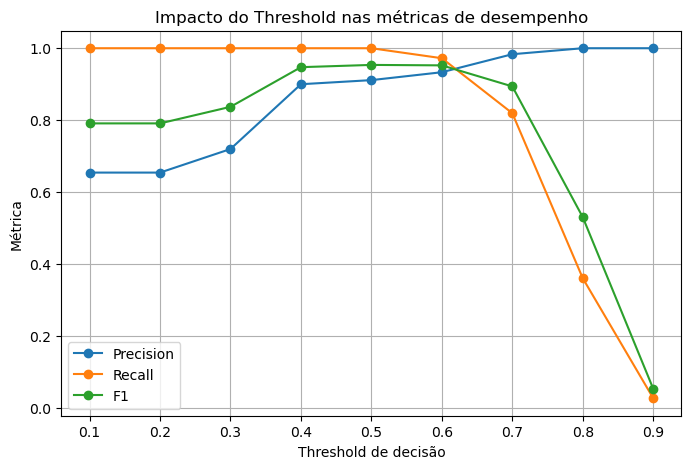

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(df_metrics["Threshold"], df_metrics["Precision"], label="Precision", marker="o")
plt.plot(df_metrics["Threshold"], df_metrics["Recall"], label="Recall", marker="o")
plt.plot(df_metrics["Threshold"], df_metrics["F1"], label="F1", marker="o")
plt.xlabel("Threshold de decisão")
plt.ylabel("Métrica")
plt.title("Impacto do Threshold nas métricas de desempenho")
plt.legend()
plt.grid(True)
plt.show()
